# Bootstrap

Instrucciones de la actividad:

-Generar muestra de tamaño 50 de alguna distribución

-Graficar la media muestreal teorica (usando Teorema Central del Limite)

-Calcular media de la media muestral usando Bootstrap

-Graficar como en clase

In [12]:
"""
Generar muestra de tamaño 50
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n = 50
lam = 2.0  # parámetro de la exponencial

muestra = np.random.exponential(scale=1/lam, size=n)

media_muestral = np.mean(muestra)
print(f"Muestra original (n={n})")
print(f"Media muestral observada: {media_muestral:.4f}")
print(f"Media teórica poblacional: {1/lam:.4f}")

Muestra original (n=50)
Media muestral observada: 0.4364
Media teórica poblacional: 0.5000


In [13]:
"""
Distribución teórica de la media muestral (TCL)
"""
# Para X ~ Exp(λ): E[X] = 1/λ, Var(X) = 1/λ²
mu_teorica = 1 / lam
sigma_teorica = np.sqrt(1 / lam**2) / np.sqrt(n)   # error estándar

print(f"\nTCL → Media ~ Normal(μ={mu_teorica:.4f}, σ={sigma_teorica:.4f})")

# Rango para graficar
x = np.linspace(mu_teorica - 4*sigma_teorica,
                mu_teorica + 4*sigma_teorica, 500)
y_teorica = stats.norm.pdf(x, loc=mu_teorica, scale=sigma_teorica)


TCL → Media ~ Normal(μ=0.5000, σ=0.0707)


In [14]:
"""
Bootstrap
"""
B = 100000  # número de remuestreos
boot_medias = np.empty(B)

for i in range(B):
    remuestra = np.random.choice(muestra, size=n, replace=True)
    boot_medias[i] = np.mean(remuestra)

media_boot = np.mean(boot_medias)
se_boot    = np.std(boot_medias, ddof=1)

print(f"\nBootstrap (B={B})")
print(f"Media de las medias bootstrap: {media_boot:.4f}")
print(f"Error estándar bootstrap     : {se_boot:.4f}")
print(f"IC 95% bootstrap             : "
      f"[{np.percentile(boot_medias,2.5):.4f}, "
      f"{np.percentile(boot_medias,97.5):.4f}]")


Bootstrap (B=100000)
Media de las medias bootstrap: 0.4364
Error estándar bootstrap     : 0.0506
IC 95% bootstrap             : [0.3412, 0.5396]


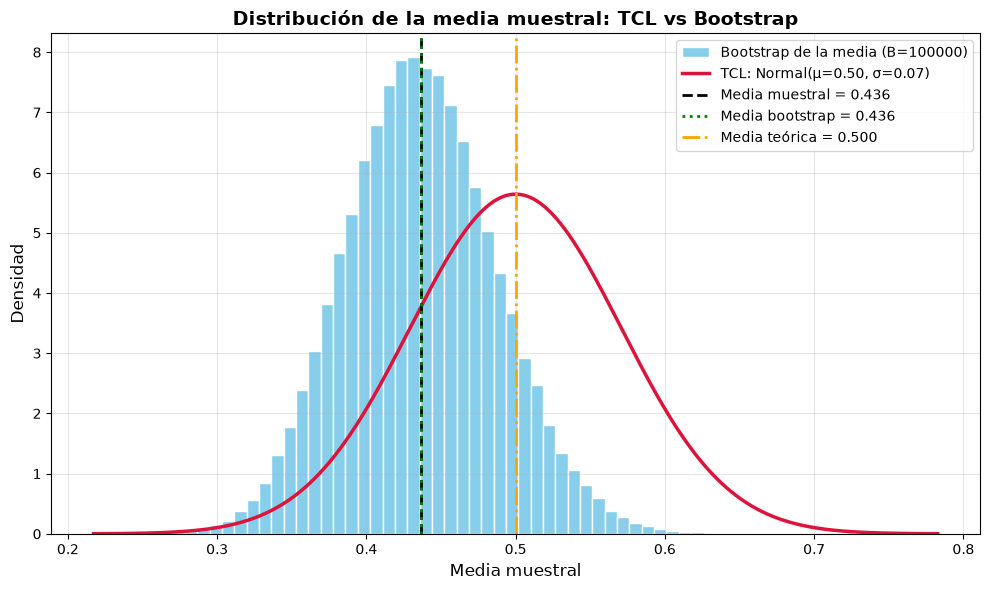

In [15]:
"""
Gráfica comparativa (estilo clase)
"""
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma bootstrap
ax.hist(boot_medias, bins=50, density=True,
        color="skyblue", edgecolor="white",
        label=f"Bootstrap de la media (B={B})")

# Curva teórica TCL
ax.plot(x, y_teorica, color="crimson", linewidth=2.5,
        label=f"TCL: Normal(μ={mu_teorica:.2f}, σ={sigma_teorica:.2f})")

# Líneas verticales
ax.axvline(media_muestral, color="black", linestyle="--", linewidth=2,
           label=f"Media muestral = {media_muestral:.3f}")
ax.axvline(media_boot, color="green", linestyle=":", linewidth=2,
           label=f"Media bootstrap = {media_boot:.3f}")
ax.axvline(mu_teorica, color="orange", linestyle="-.", linewidth=2,
           label=f"Media teórica = {mu_teorica:.3f}")

ax.set_title("Distribución de la media muestral: TCL vs Bootstrap",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Media muestral", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()